Random Forest Model Performance
----------------------------------
Accuracy: 0.6666666666666666

Confusion Matrix:
 [[752 353]
 [385 724]]

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.68      0.67      1105
           1       0.67      0.65      0.66      1109

    accuracy                           0.67      2214
   macro avg       0.67      0.67      0.67      2214
weighted avg       0.67      0.67      0.67      2214

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   8.3s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  10.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   9.2s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   8.2s
[CV] END max_depth=10, min_samples_leaf=1, 

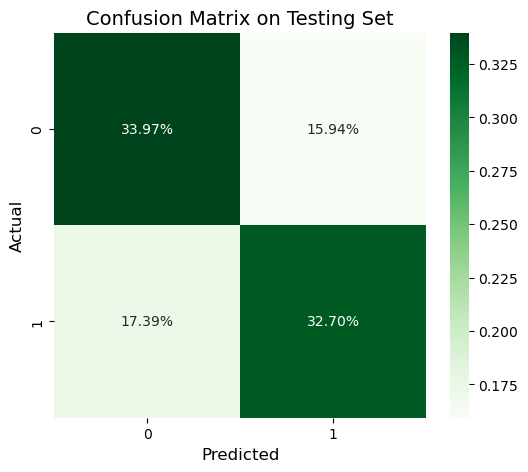

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Load the PCA-compressed dataset
data_path = '../cyberbullying_datasets/course_dataset/cb_pca_compressed.csv.gz'
data = pd.read_csv(data_path)

# 2. Split features (X) and labels (y)
# Assuming the last column is the label (0 or 1)
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# 3. Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Initialize and train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,      # number of trees
    max_depth=None,        # allow full growth
    random_state=42,
    n_jobs=-1              # use all CPU cores
)

rf_model.fit(X_train, y_train)

# 5. Predictions
y_pred = rf_model.predict(X_test)

# 6. Evaluation
print("Random Forest Model Performance")
print("----------------------------------")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Grid search

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=2
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

# Confusion matrix heatmap

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import seaborn as sns

# Confusion matrix heatmap
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
sns.heatmap(
    confusion_matrix(y_test, y_pred, normalize='all'),
    annot=True, fmt='.2%', cmap='Greens', ax=ax
)

ax.set_title('Confusion Matrix on Testing Set', fontsize=14)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)

plt.show()


Random Forest Model Performance
----------------------------------
Accuracy: 0.6738934056007226

Confusion Matrix:
 [[770 335]
 [387 722]]

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.70      0.68      1105
           1       0.68      0.65      0.67      1109

    accuracy                           0.67      2214
   macro avg       0.67      0.67      0.67      2214
weighted avg       0.67      0.67      0.67      2214



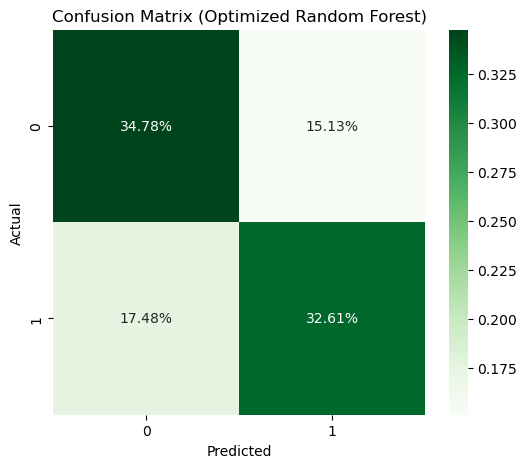

In [3]:
# 4. Initialize and train Random Forest
rf_best = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

rf_best.fit(X_train, y_train)

# 5. Predictions
y_pred = rf_best.predict(X_test)

# 6. Evaluation
print("Random Forest Model Performance")
print("----------------------------------")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
sns.heatmap(
    confusion_matrix(y_test, y_pred, normalize='all'),
    annot=True, fmt='.2%', cmap='Greens', ax=ax
)

ax.set_title('Confusion Matrix (Optimized Random Forest)')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.show()